Loading dataset...
Data shape: (494021, 42)
Performing one-hot encoding for categorical features...
Scaling numerical features...
Processed data shape: (494021, 118)
Splitting data into training (normal) and test sets...
Training samples: 77822, Validation samples: 19456, Test samples: 494021
Building the autoencoder model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          15,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 118)                 │          15,222 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,222 (200.09 KB)

 Trainable params: 51,222 (200.09 KB)

 Non-trainable params: 0 (0.00 B)

Training the autoencoder...
Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.3322 - val_loss: 0.2716
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1509 - val_loss: 0.2677
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2102 - val_loss: 0.1185
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0895 - val_loss: 0.1232
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0739 - val_loss: 0.1767
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0879 - val_loss: 0.1219
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0366 - val_loss: 0.1240
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0552 - val_loss: 0.4689


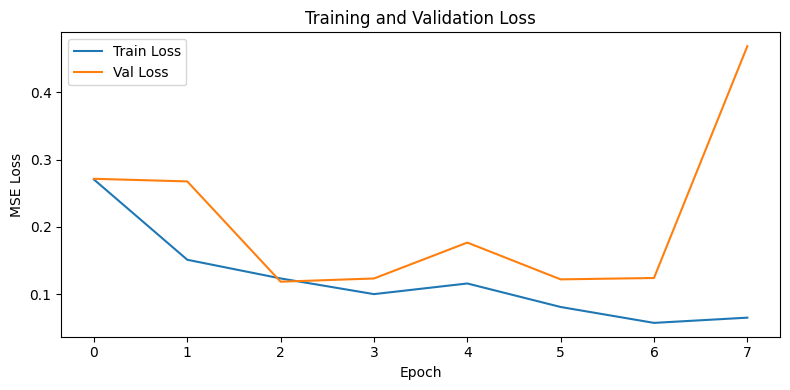

Evaluating on the test set...
15439/15439 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step
2432/2432 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Reconstruction error threshold: 0.039654661110010786
ROC AUC Score: 0.9865


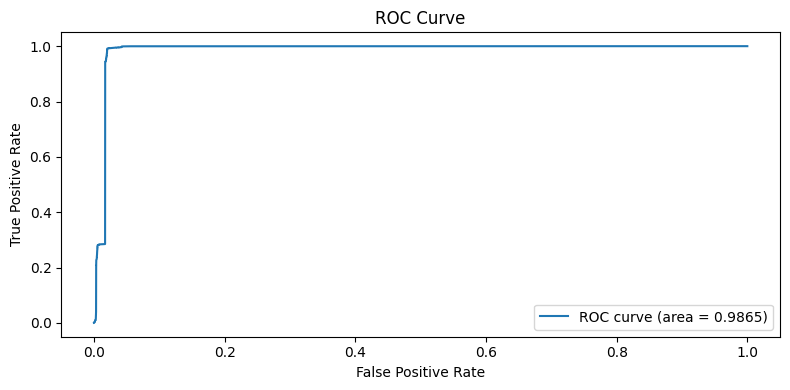

Confusion Matrix:
[[ 92419   4859]
 [   201 396542]]
Classification Report:


              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     97278
     Anomaly       0.99      1.00      0.99    396743

    accuracy                           0.99    494021
   macro avg       0.99      0.97      0.98    494021
weighted avg       0.99      0.99      0.99    494021

Model saved as 'autoencoder_model.h5'.


In [ ]:
"""
Network Traffic Anomaly Detection Using an Autoencoder

This script uses the KDD Cup 99 dataset (available via scikit-learn) to build an autoencoder
for anomaly detection. The autoencoder is trained only on normal data, and reconstruction error is
used to detect anomalous network traffic.

Before running, install the necessary packages:
    pip install numpy pandas scikit-learn matplotlib tensorflow

Usage:
    python network_anomaly_detection.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.datasets import fetch_kddcup99

# --------------------------
# 1. Data Loading and Preprocessing
# --------------------------

print("Loading dataset...")
# Fetch the KDD Cup 99 dataset (using 10% of the data for speed)
data = fetch_kddcup99(percent10=True)
X = data.data  # features
y = data.target  # labels

# The dataset features are in a numpy array with dtype=object (bytes), so we need to decode them.
# The dataset has 41 features. According to documentation, columns 1, 2, 3 are categorical:
categorical_indices = [1, 2, 3]
X_decoded = np.copy(X)
for idx in categorical_indices:
    # Decode bytes to string
    X_decoded[:, idx] = np.array([x.decode('utf-8') for x in X[:, idx]])

# Decode the labels as well
y_decoded = np.array([x.decode('utf-8') for x in y])

# Create a DataFrame with appropriate column names.
# Column names based on KDD Cup 99 feature description.
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]
df = pd.DataFrame(X_decoded, columns=col_names)
df['target'] = y_decoded

print("Data shape:", df.shape)

# Separate features and labels
X_df = df.drop('target', axis=1)
y_series = df['target']

# Identify categorical and numerical features.
categorical_features = ['protocol_type', 'service', 'flag']
numerical_features = [col for col in X_df.columns if col not in categorical_features]

# One-hot encode categorical features.
print("Performing one-hot encoding for categorical features...")
encoder = OneHotEncoder(sparse_output=False)

X_cat = encoder.fit_transform(X_df[categorical_features])
# Get one-hot encoded column names (optional)
encoded_cols = encoder.get_feature_names_out(categorical_features)
df_cat = pd.DataFrame(X_cat, columns=encoded_cols, index=X_df.index)

# Standardize numerical features.
print("Scaling numerical features...")
scaler = StandardScaler()
X_num = scaler.fit_transform(X_df[numerical_features])
df_num = pd.DataFrame(X_num, columns=numerical_features, index=X_df.index)

# Combine processed features.
X_processed = pd.concat([df_num, df_cat], axis=1)
print("Processed data shape:", X_processed.shape)

# --------------------------
# 2. Split the Data
# --------------------------
# For unsupervised anomaly detection, we assume that only "normal" data is available for training.
# In the KDD dataset, the label 'normal.' indicates normal traffic.
print("Splitting data into training (normal) and test sets...")
normal_data = X_processed[y_series == 'normal.']
anomalous_data = X_processed[y_series != 'normal.']

# For training, use only normal data.
X_train = normal_data.values

# For testing, combine normal and anomalous instances.
X_test = X_processed.values
y_test = np.where(y_series == 'normal.', 0, 1)  # 0: normal, 1: anomaly

# Optionally, you can further split the normal training data into training and validation sets.
X_train, X_val = train_test_split(X_train, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")

# --------------------------
# 3. Build the Autoencoder Model
# --------------------------
input_dim = X_train.shape[1]
encoding_dim = 32  # You can adjust this hyperparameter.

print("Building the autoencoder model...")
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(encoding_dim, activation='relu', name='bottleneck'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(input_dim, activation='linear')  # linear output for regression of inputs
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# --------------------------
# 4. Train the Autoencoder
# --------------------------
print("Training the autoencoder...")
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val, X_val),
    callbacks=[early_stop]
)

# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png")
plt.show()

# --------------------------
# 5. Evaluate the Model for Anomaly Detection
# --------------------------
print("Evaluating on the test set...")
# Compute reconstruction error for test set
X_test_pred = model.predict(X_test)
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# Set a threshold. One way is to use the 95th percentile of reconstruction errors on the training data.
X_train_pred = model.predict(X_train)
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
threshold = np.percentile(mse_train, 95)
print("Reconstruction error threshold:", threshold)

# Flag anomalies where reconstruction error > threshold.
y_pred = (mse > threshold).astype(int)

# Compute evaluation metrics.
auc = roc_auc_score(y_test, mse)
print(f"ROC AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, mse)
plt.figure(figsize=(8, 4))
plt.plot(fpr, tpr, label=f'ROC curve (area = {auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# --------------------------
# 6. Save the Model
# --------------------------
model.save("autoencoder_model.h5")
print("Model saved as 'autoencoder_model.h5'.")
